In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from finite_diff_functions import *

# Exersice 2a

## (a)

## (b)

First we code up for a global linear BVP:

In [19]:
eps = 0.1
a = 0
b = 1
alpha = 0
beta = np.sin(1)
w0 = 0.5*(a - b + beta - alpha)
xtilde = 0.5*(a + b - alpha - beta)

# mesh
x = np.linspace(a, b, 4)
n = len(x)

# Method of Manufactured solution (MoMS)
u_man = lambda x: np.sin(x)
f = - (eps + 1) * np.sin(x)

stencil = np.array([-1, 0, 1])

D2 = fdcoeffV_uniform(2, x[1] - x[0], stencil) * eps
D0 = fdcoeffV_uniform(1, x[1] - x[0], stencil)
D2, D0

(array([ 0.9, -1.8,  0.9]), array([-1.5,  0. ,  1.5]))

In [20]:
sub_diag = np.full(n-1, D2[0])
d = np.full(n, D2[1])
sup_diag = np.full(n-1, D2[2])

A = np.diag(sub_diag, -1) + np.diag(d) + np.diag(sup_diag, 1) - np.eye(n)

In [21]:
A

array([[-2.8,  0.9,  0. ,  0. ],
       [ 0.9, -2.8,  0.9,  0. ],
       [ 0. ,  0.9, -2.8,  0.9],
       [ 0. ,  0. ,  0.9, -2.8]])

In [22]:
u_FD = np.linalg.solve(A, f)

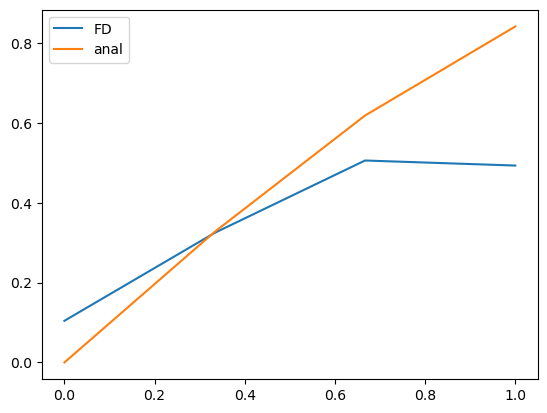

In [23]:
plt.plot(x, u_FD, label = 'FD')
plt.plot(x, u_man(x), label = 'anal')
plt.legend()
plt.show()

### Non-linear

In [24]:
eps = 0.1
a = 0
b = 1
alpha = -1
beta = 1.5
w0 = 0.5*(a - b + beta - alpha)
xtilde = 0.5*(a + b - alpha - beta)

# mesh
x = np.linspace(a, b, 50)


initial_guess = x - xtilde + w0*np.tanh(w0*(x - xtilde) / 2 * eps)